# Natural Language Processing (NLP) with Machine Learning

---

## Topics Covered

- **Text Vectorization:** Bag of Words (BoW)
- **Multilingual BoW:** CountVectorizer with custom tokenizer
- **TF-IDF Representation:** TfidfVectorizer
- **Data Loading:** Pandas + Excel
- **Text Classification:** Logistic Regression + Cross-Validation
- **Performance Evaluation:** Accuracy, Precision, Recall, F1-Score, Confusion Matrix
- **Model Comparison:** Logistic Regression, SVM, Random Forest


## Mount Google Drive

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bag of Words (BoW)


In [25]:
from numpy import vectorize
from sklearn.feature_extraction.text import CountVectorizer

texts = [
    "I love this movie",
    "I love this cat"
]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(texts)

print("Vocabulary:")
print(vectorizer.vocabulary_)

print(vectorizer.get_feature_names_out())

print("\nVectorized Texts:")
print(X.toarray())

Vocabulary:
{'love': 1, 'this': 3, 'movie': 2, 'cat': 0}
['cat' 'love' 'movie' 'this']

Vectorized Texts:
[[0 1 1 1]
 [1 1 0 1]]


## TF-IDF Vectorization


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = [
    "মুভিটি খুব ভালো",
    "মুভিটি খুব বাজে"
]

vectorizer = TfidfVectorizer(
    tokenizer = lambda x: x.split(),
    token_pattern = None
)

X = vectorizer.fit_transform(texts)

print(vectorizer.get_feature_names_out())

print("\nVectorized Texts:")
print(X.toarray())

['খুব' 'বাজে' 'ভালো' 'মুভিটি']

Vectorized Texts:
[[0.50154891 0.         0.70490949 0.50154891]
 [0.50154891 0.70490949 0.         0.50154891]]


In [27]:
import pandas as pd
import numpy as np

path=r"//content/drive/MyDrive/data set!!/E-commerce.xlsx"
df=pd.read_excel(path)
df.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


,Name,Comment,Tag
0,Monirul Ahmed,"আদৌও কি আমার রিফান্ড পাবো, প্রিয় ই- ভালি?????...",Bad
1,Tanzil Ayon,আপনাদের প্রায়োরিটি স্টোর/ T10 এর আগের পণ্য গু...,Bad
2,HM Athir Al Azad,Order করেছি কিন্তু এখনো নোটিফিকেশন এর মাধ্যমে ...,Bad
3,মোহাম্মদ ইকবাল হোসাইন রুবেল,পেমেন্ট করতে চাইলে নিচের মেসেজ টা শো করছে।আমার...,Neutral
4,DrSheikh Rumi,msung M01s) এটা ৭ দিনের গ্যারান্টেড ডেলিভারির ...,Bad


## Extract Features & Labels (E-Commerce)

We split the dataset into:

- **X** → input data (text/comments)
- **y** → output data (labels/categories)

In [28]:
X = df['Comment']
y = df['Tag']
X,y

(0      আদৌও কি আমার রিফান্ড পাবো, প্রিয় ই- ভালি?????...
 1      আপনাদের প্রায়োরিটি স্টোর/ T10 এর আগের পণ্য গু...
 2      Order করেছি কিন্তু এখনো নোটিফিকেশন এর মাধ্যমে ...
 3      পেমেন্ট করতে চাইলে নিচের মেসেজ টা শো করছে।আমার...
 4      msung M01s) এটা ৭ দিনের গ্যারান্টেড ডেলিভারির ...
                              ...                        
 944    শুধু চীন নয়, আরো দেশ থেকে আরো ক্রস বর্ডার পণ্...
 945    আমি দারাজ মূলকে ভালোবাসি কারণ 10% ক্যাশব্যাক +...
 946    দারাজমল 100% প্রামাণিক পণ্য ডেলিভারি দে .. আইখ...
 947    আজ অবধি, আল্লাহর রহমতে আমি দারাজ থেকে যতটা সম্...
 948    আগামি 10 বছর একটি দারাজ পৃথীবির পোটাক্তা কোনায...
 Name: Comment, Length: 949, dtype: object,
 0          Bad
 1          Bad
 2          Bad
 3      Neutral
 4          Bad
         ...   
 944    Neutral
 945       Good
 946       Good
 947       Good
 948    Neutral
 Name: Tag, Length: 949, dtype: object)

## Load Social Media Comment Dataset

In [29]:
df = pd.read_excel(r'/content/drive/MyDrive/data set!!/social_media_comment.xlsx')
df.head()

,Comment,Sentiment
0,কোনো সমস্যা নেই! আপনার মতামত প্রকাশ করতে হলে স...,Neutral
1,যোগা কিশোরী সম্পর্কেও আপনার অনুভূতি জানালে ভাল...,Neutral
2,সবচেয়ে বাজে হলো প্রিয়তমা। গল্প + dialogue +গ...,Negative
3,শাকিব খানের অভিনয় অসাধারণ এবং তার পরিবর্তিত l...,Positive
4,ছবির গল্পটি রোমাঞ্চকর এবং thrillerএর উপাদান যু...,Positive


## Extract Features & Labels (Social Media)

We split the dataset into:

- **X** → comment text (input data)
- **y** → sentiment label (output data)

In [30]:
X = df['Comment']
y = df['Sentiment']
X,y

(0       কোনো সমস্যা নেই! আপনার মতামত প্রকাশ করতে হলে স...
 1       যোগা কিশোরী সম্পর্কেও আপনার অনুভূতি জানালে ভাল...
 2       সবচেয়ে বাজে হলো প্রিয়তমা। গল্প + dialogue +গ...
 3       শাকিব খানের অভিনয় অসাধারণ এবং তার পরিবর্তিত l...
 4       ছবির গল্পটি রোমাঞ্চকর এবং thrillerএর উপাদান যু...
                               ...                        
 8326    অভিনয়ের অনেক কিছুই হালকা লাগছিল, কিছু দৃশ্যে ...
 8327    গল্পটা কোথাও গলদ ছিল, অনেক কিছু অবাস্তব মনে হয...
 8328    শাবনুরের চরিত্রটা আমার কাছে খুবই অপ্রাসঙ্গিক ম...
 8329    কিছু সংলাপ অনেক ঝাল মনে হয়েছে, আরও মজার হতে প...
 8330     পুরো cinema দেখতে দেখতে ক্লান্ত হয়ে গিয়েছিলাম।
 Name: Comment, Length: 8331, dtype: object,
 0        Neutral
 1        Neutral
 2       Negative
 3       Positive
 4       Positive
           ...   
 8326    Negative
 8327    Negative
 8328    Negative
 8329     Neutral
 8330    Negative
 Name: Sentiment, Length: 8331, dtype: object)

## Build ML Pipeline & Cross-Validation (Logistic Regression)

A **Pipeline** connects all steps of machine learning in one flow.

### What it does:

- Converts text into numbers using **CountVectorizer**
- Trains the model using **Logistic Regression**
- Ensures no data leakage (training data only)
- Makes the process simple and clean

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

pipeline = Pipeline([
    (
        "tfidf",
        CountVectorizer(
          tokenizer = lambda x: x.split(),
          token_pattern = None
      )
    ),
    (
        "model",
        LogisticRegression(max_iter=1000, random_state=42)
    )
])

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(
    pipeline,
    X,
    y,
    cv = kfold
)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


## Inspect Predictions

We check the predicted results stored in **y_pred** to make sure the model worked correctly.

This helps us confirm that cross-validation and prediction steps ran successfully.

In [32]:
y_pred

array(['Negative', 'Negative', 'Positive', ..., 'negative', 'Neutral',
       'Positive'], dtype=object)

## Evaluation Metrics

We use some basic metrics to check model performance:

- **Accuracy** → total correct predictions  
- **Precision** → correct positive predictions  
- **Recall** → how many real positives are found  
- **F1 Score** → balance between precision and recall  

> We use **weighted average** to handle different class sizes.

In [33]:
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, average='weighted')
recall = recall_score(y, y_pred, average='weighted')
f1 = f1_score(y, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.7222422278237907
Precision: 0.6962296994682033
Recall: 0.7222422278237907
F1 Score: 0.7003755602798143


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Full Classification Report

**classification_report** shows detailed results for each class.

It includes:
- Precision
- Recall
- F1 Score

It also gives overall average scores.

This is more useful than only accuracy, especially for multi-class or imbalanced data.

In [34]:
class_report = classification_report(y, y_pred)
print(class_report)

                                                     precision    recall  f1-score   support

                 Mixed (Negative + Slight Positive)       0.00      0.00      0.00         1
                         Mixed (Neutral + Positive)       0.00      0.00      0.00         1
                        Mixed (Positive + Negative)       0.00      0.00      0.00         3
                 Mixed (Positive + Slight Negative)       0.00      0.00      0.00         3
     Mixed (Positive for acting, Negative for plot)       0.00      0.00      0.00         1
Mixed (Positive for last 20 mins, Negative overall)       0.00      0.00      0.00         1
  Mixed (Positive for শরিফুল রাজ, Negative overall)       0.00      0.00      0.00         1
                 Mixed (Slight Negative + Positive)       0.00      0.00      0.00        17
                Mixed (Slight Positive + Skeptical)       0.00      0.00      0.00         1
                                           Negative       0.65      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Inspect Unique Sentiment Labels

We check the different sentiment labels available in the dataset.

This helps us understand what types of sentiment classes exist.

In [35]:
df['Sentiment'].unique()

array(['Neutral', 'Negative', 'Positive',
       'Mixed (Positive for last 20 mins, Negative overall)',
       'Mixed (Positive + Slight Negative)',
       'Mixed (Positive + Negative)', 'Mixed (Neutral + Positive)',
       'Mixed (Negative + Slight Positive)',
       'Mixed (Slight Negative + Positive)',
       'Mixed (Slight Positive + Skeptical)',
       'Mixed (Positive for শরিফুল রাজ, Negative overall)',
       'Mixed (Positive for acting, Negative for plot)', 'negative',
       'neutral', 'positive', 'mixed'], dtype=object)

## Confusion Matrix

The confusion matrix compares actual labels with predicted labels.

- **Diagonal values** → correct predictions  
- **Other values** → wrong predictions  

This helps us understand where the model makes mistakes.

In [36]:
cm = confusion_matrix(y, y_pred)
print(cm)

[[   0    0    0    0    0    0    0    0    0    1    0    0    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    0    1    0    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    1    2    0    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    0    3    0    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    0    1    0    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    1    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    0    1    0    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    2    9    5    0    1
     0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    1    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0 1231  245  187    0  123
     0    8]
 [   0    0    0    0    0    0    0    0    0  228 2386  151    0   26
     4   12]
 [   0    0    0    0    0    0    0    0    0  106  113 2170    

## Confusion Matrix Visualization

We visualize the confusion matrix to better understand model performance.

It helps to:
- See correct and wrong predictions
- Find where the model makes mistakes
- Compare predicted labels with actual labels

We use **ConfusionMatrixDisplay** and **matplotlib** to create the visualization.

/tmp/ipykernel_6779/1820987279.py:20: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/1820987279.py:20: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_6779/1820987279.py:20: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/1820987279.py:20: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/1820987279.py:20: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/1820987279.py:20: UserWarning: Glyph 2497 (\N{BENGALI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/1820987279.py:20: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_677

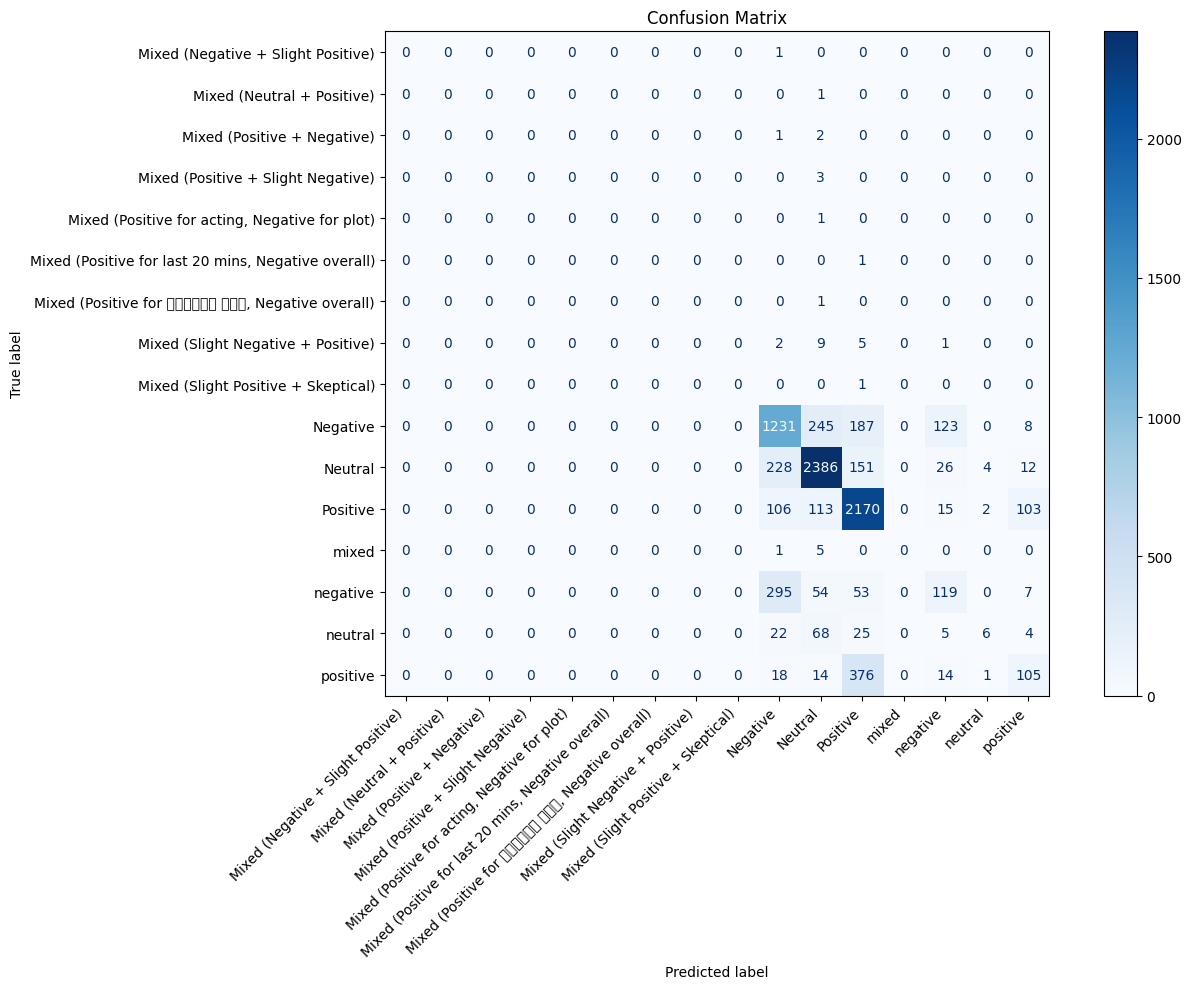

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

label = np.unique(y)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label
)

fig, ax = plt.subplots(figsize=(14,10))

disp.plot(ax=ax, cmap='Blues')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

## Model Comparison: Logistic Regression vs SVM vs Random Forest

We compare different machine learning models to see which performs better.

### Models Used

- **Logistic Regression** → simple and fast model  
- **SVM** → works well for text classification  
- **Random Forest** → tree-based model for better prediction  

### Process

For each model:

1. Convert text into numbers using **CountVectorizer**
2. Train the model
3. Use cross-validation for testing
4. Check performance using:
   - Accuracy
   - Precision
   - Recall
   - F1 Score

The model with better performance is selected.

Model: Logistic Regression
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.7222
Precision: 0.6962
Recall: 0.7222
F1 Score: 0.7004


/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2497 (\N{BENGALI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/50496

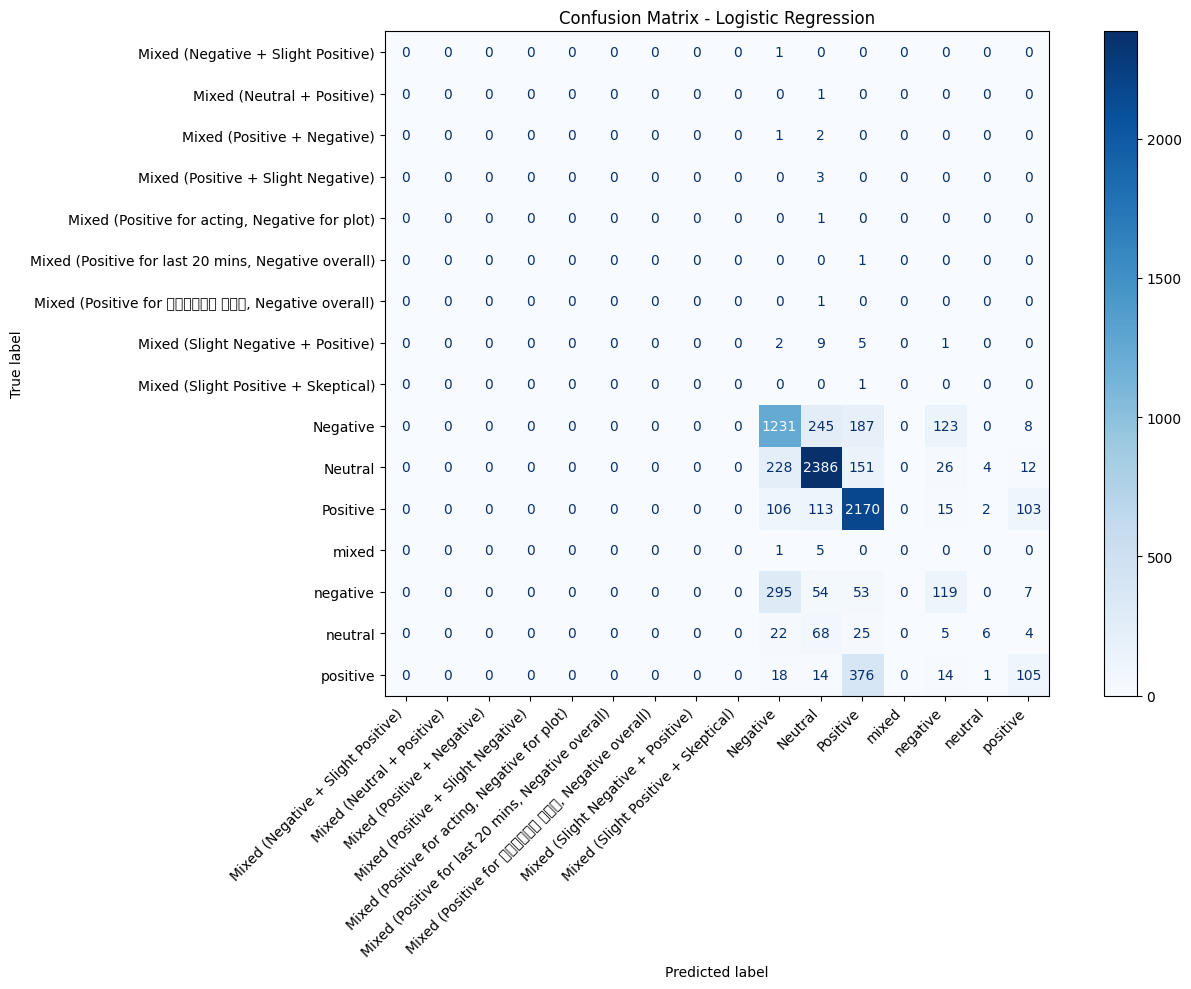

Model: Linear SVC
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.6987
Precision: 0.6850
Recall: 0.6987
F1 Score: 0.6910


/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2497 (\N{BENGALI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/50496

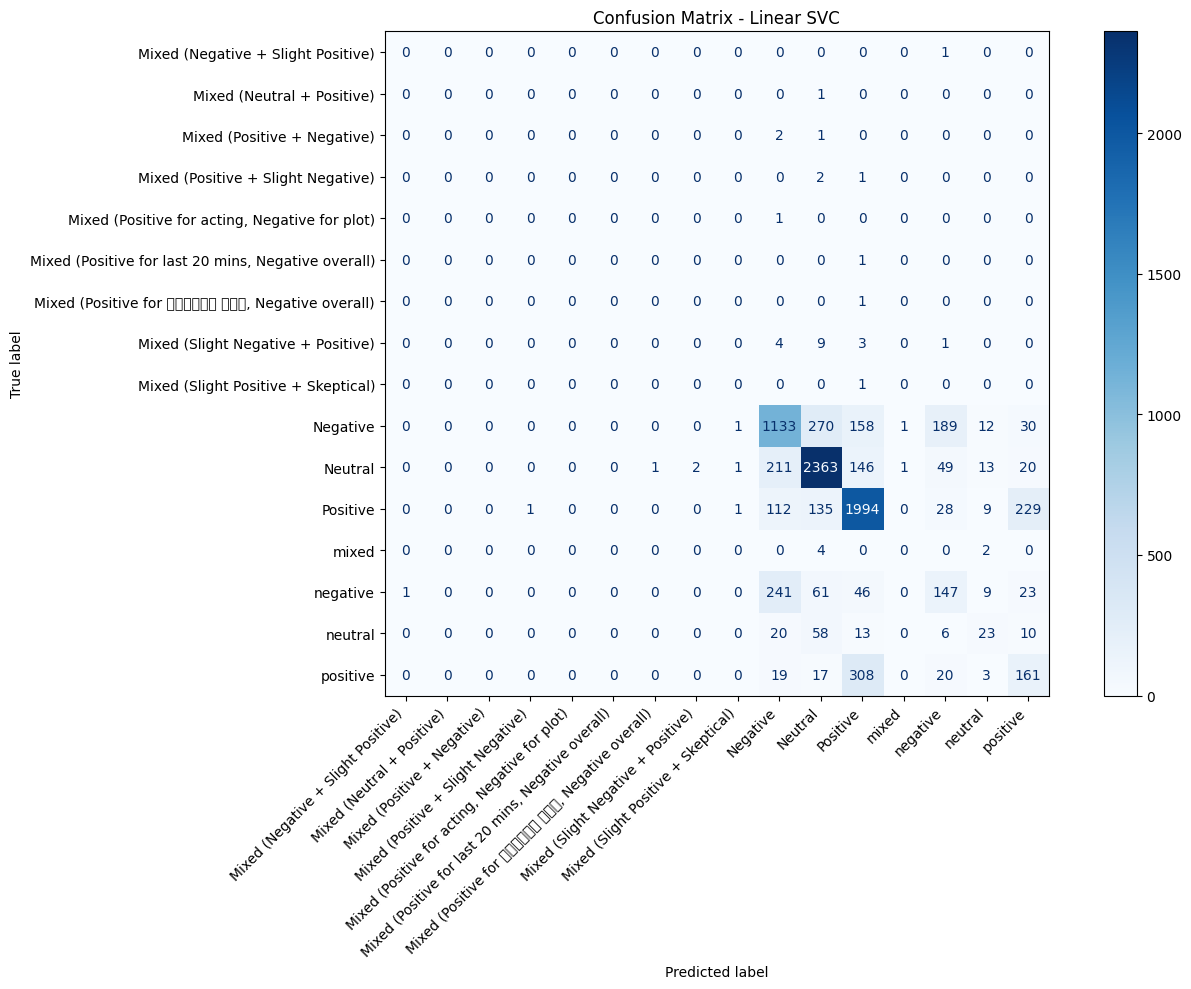

Model: Random Forest
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.7180
Precision: 0.7190
Recall: 0.7180
F1 Score: 0.6817


/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2497 (\N{BENGALI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/504968247.py:59: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6779/50496

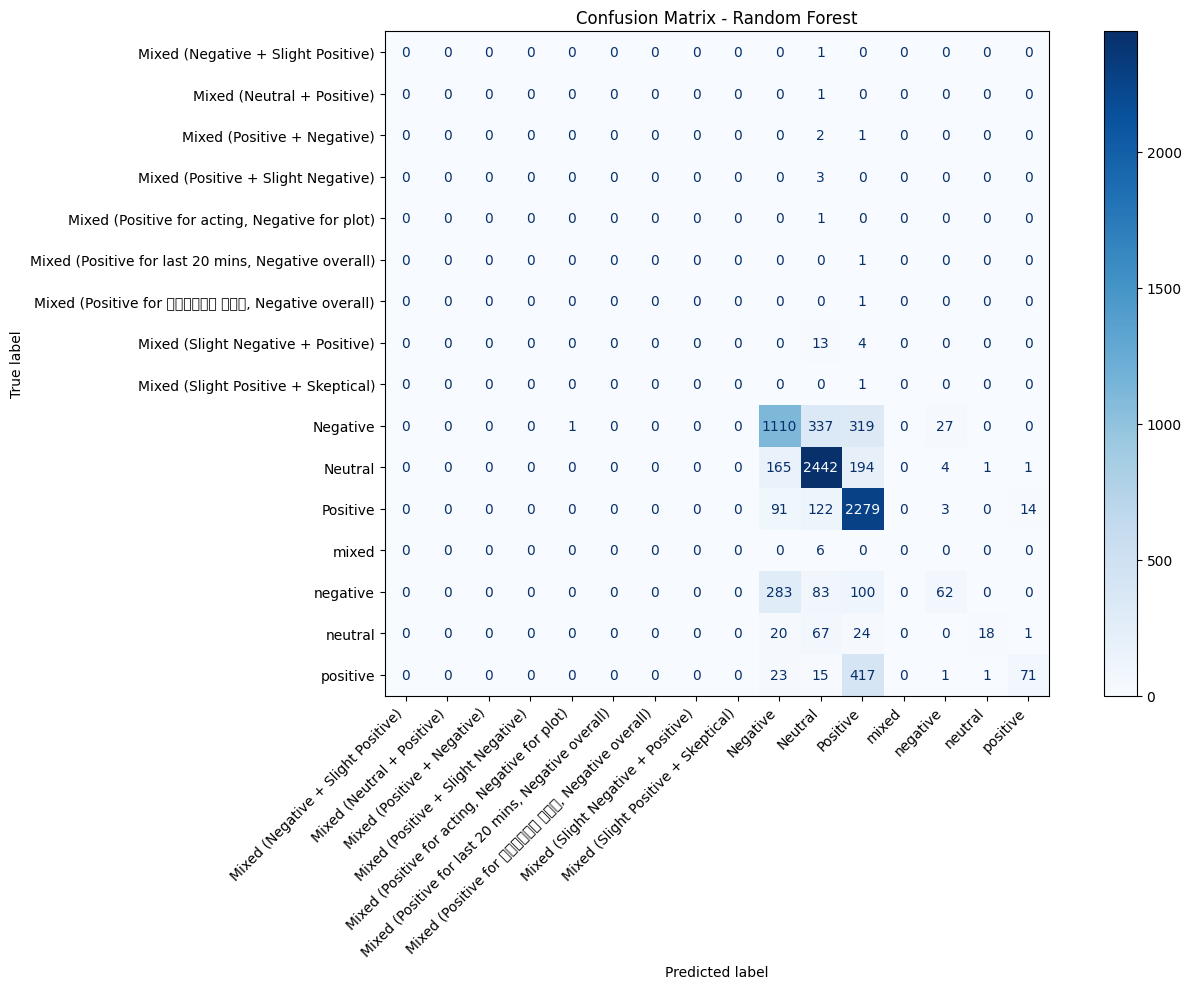

In [38]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

random_state = 42

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=random_state),
    "Linear SVC": LinearSVC(random_state=random_state),
    "Random Forest": RandomForestClassifier(random_state=random_state)
}

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

for model_name, model in models.items():

    print(f"Model: {model_name}")
    print("-" * 50)

    pipeline = Pipeline([
        ("tfidf", CountVectorizer(tokenizer=lambda x: x.split(), token_pattern=None)),
        ("model", model)
    ])

    y_pred = cross_val_predict(pipeline, X, y, cv=kfold)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average='weighted')
    recall = recall_score(y, y_pred, average='weighted')
    f1 = f1_score(y, y_pred, average='weighted')

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    label = np.unique(y)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label
    )

    fig, ax = plt.subplots(figsize=(14, 10))  # বড় figure

    disp.plot(ax=ax, cmap='Blues')

    plt.xticks(rotation=45, ha='right')  # label overlap fix
    plt.yticks(rotation=0)

    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()

    plt.savefig(
        f"confusion_matrix_{model_name.replace(' ', '_')}.png",
        dpi=300
    )

    plt.show()

# Home Work
Adding **class_weight=balanced**

In [39]:
y_pred


array(['Negative', 'Negative', 'Negative', ..., 'Negative', 'Neutral',
       'negative'], dtype=object)

In [40]:
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, average='weighted')
recall = recall_score(y, y_pred, average='weighted')
f1 = f1_score(y, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.7180410514944184
Precision: 0.718996379039591
Recall: 0.7180410514944184
F1 Score: 0.681652445179849


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
